# *Stellar Class||EDA+Feature Engineer+LGB***

# Import Labraries

In [1]:
# Importing and loading necessary libraries and packages
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='white', palette='Set2')

import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_sample_weight


import warnings
warnings.filterwarnings('ignore')

# EDA

In [2]:
# Loading in the datasets
df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
df_test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')

In [3]:
# Viewing first 5 entries of 'df_train'
df_train.head(10)

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
5,5,250.727869,31.756548,20.926469,19.693480,18.902361,19.247572,18.508241,0.076299,G/K,Blue_Cloud,STAR
6,6,0.752529,-2.936677,22.829195,22.686143,20.583886,19.781338,19.410491,0.575080,M,Red_Sequence,GALAXY
7,7,235.611325,39.626517,22.511467,21.480306,21.765645,21.508658,21.333476,2.159269,O/B,Blue_Cloud,QSO
8,8,355.359230,2.182312,20.396550,20.064767,19.892257,19.836272,19.860081,0.900087,A/F,Blue_Cloud,QSO
9,9,254.980080,38.743449,18.839137,17.997845,18.458894,18.229552,19.202247,0.114302,O/B,Blue_Cloud,STAR


In [4]:
# Creating a function to show a summary of a given dataset
def show_sum(df):
    sum_df = pd.DataFrame(index=list(df))
    sum_df['Dtype']    = df.dtypes
    sum_df['Count']    = df.count()
    sum_df['#Unique']  = df.nunique()
    sum_df['#Missing'] = df.isnull().sum()
    sum_df['%Missing'] = (df.isnull().sum() / len(df) * 100).round(2)
    return sum_df

In [5]:
# Examining summary of 'df_train'
show_sum(df_train)

,Dtype,Count,#Unique,#Missing,%Missing
id,int64,577347,577347,0,0.0
alpha,float64,577347,439819,0,0.0
delta,float64,577347,444062,0,0.0
u,float64,577347,577347,0,0.0
g,float64,577347,577347,0,0.0
r,float64,577347,577347,0,0.0
i,float64,577347,577347,0,0.0
z,float64,577347,577347,0,0.0
redshift,float64,577347,573975,0,0.0
spectral_type,object,577347,4,0,0.0


In [6]:
# Examining summary of 'df_test'
show_sum(df_test)

,Dtype,Count,#Unique,#Missing,%Missing
id,int64,247435,247435,0,0.0
alpha,float64,247435,200893,0,0.0
delta,float64,247435,201819,0,0.0
u,float64,247435,247435,0,0.0
g,float64,247435,247435,0,0.0
r,float64,247435,247435,0,0.0
i,float64,247435,247435,0,0.0
z,float64,247435,247435,0,0.0
redshift,float64,247435,246031,0,0.0
spectral_type,object,247435,4,0,0.0


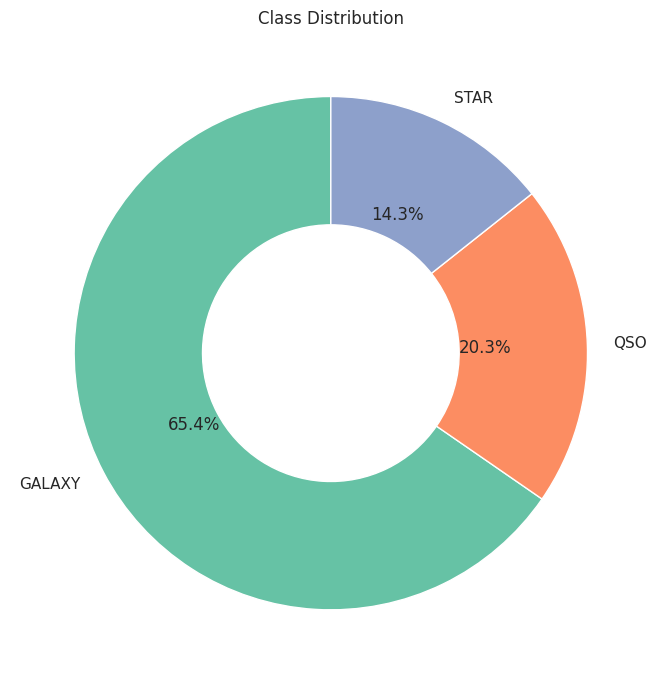

In [7]:
# Creating donut chart for target variable 'Irrigation_Need'
counts = df_train['class'].value_counts().reindex(['GALAXY', 'QSO', 'STAR'])
plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2'),
    wedgeprops=dict(width=0.5),
    startangle=90
)
plt.title('Class Distribution')
plt.tight_layout()

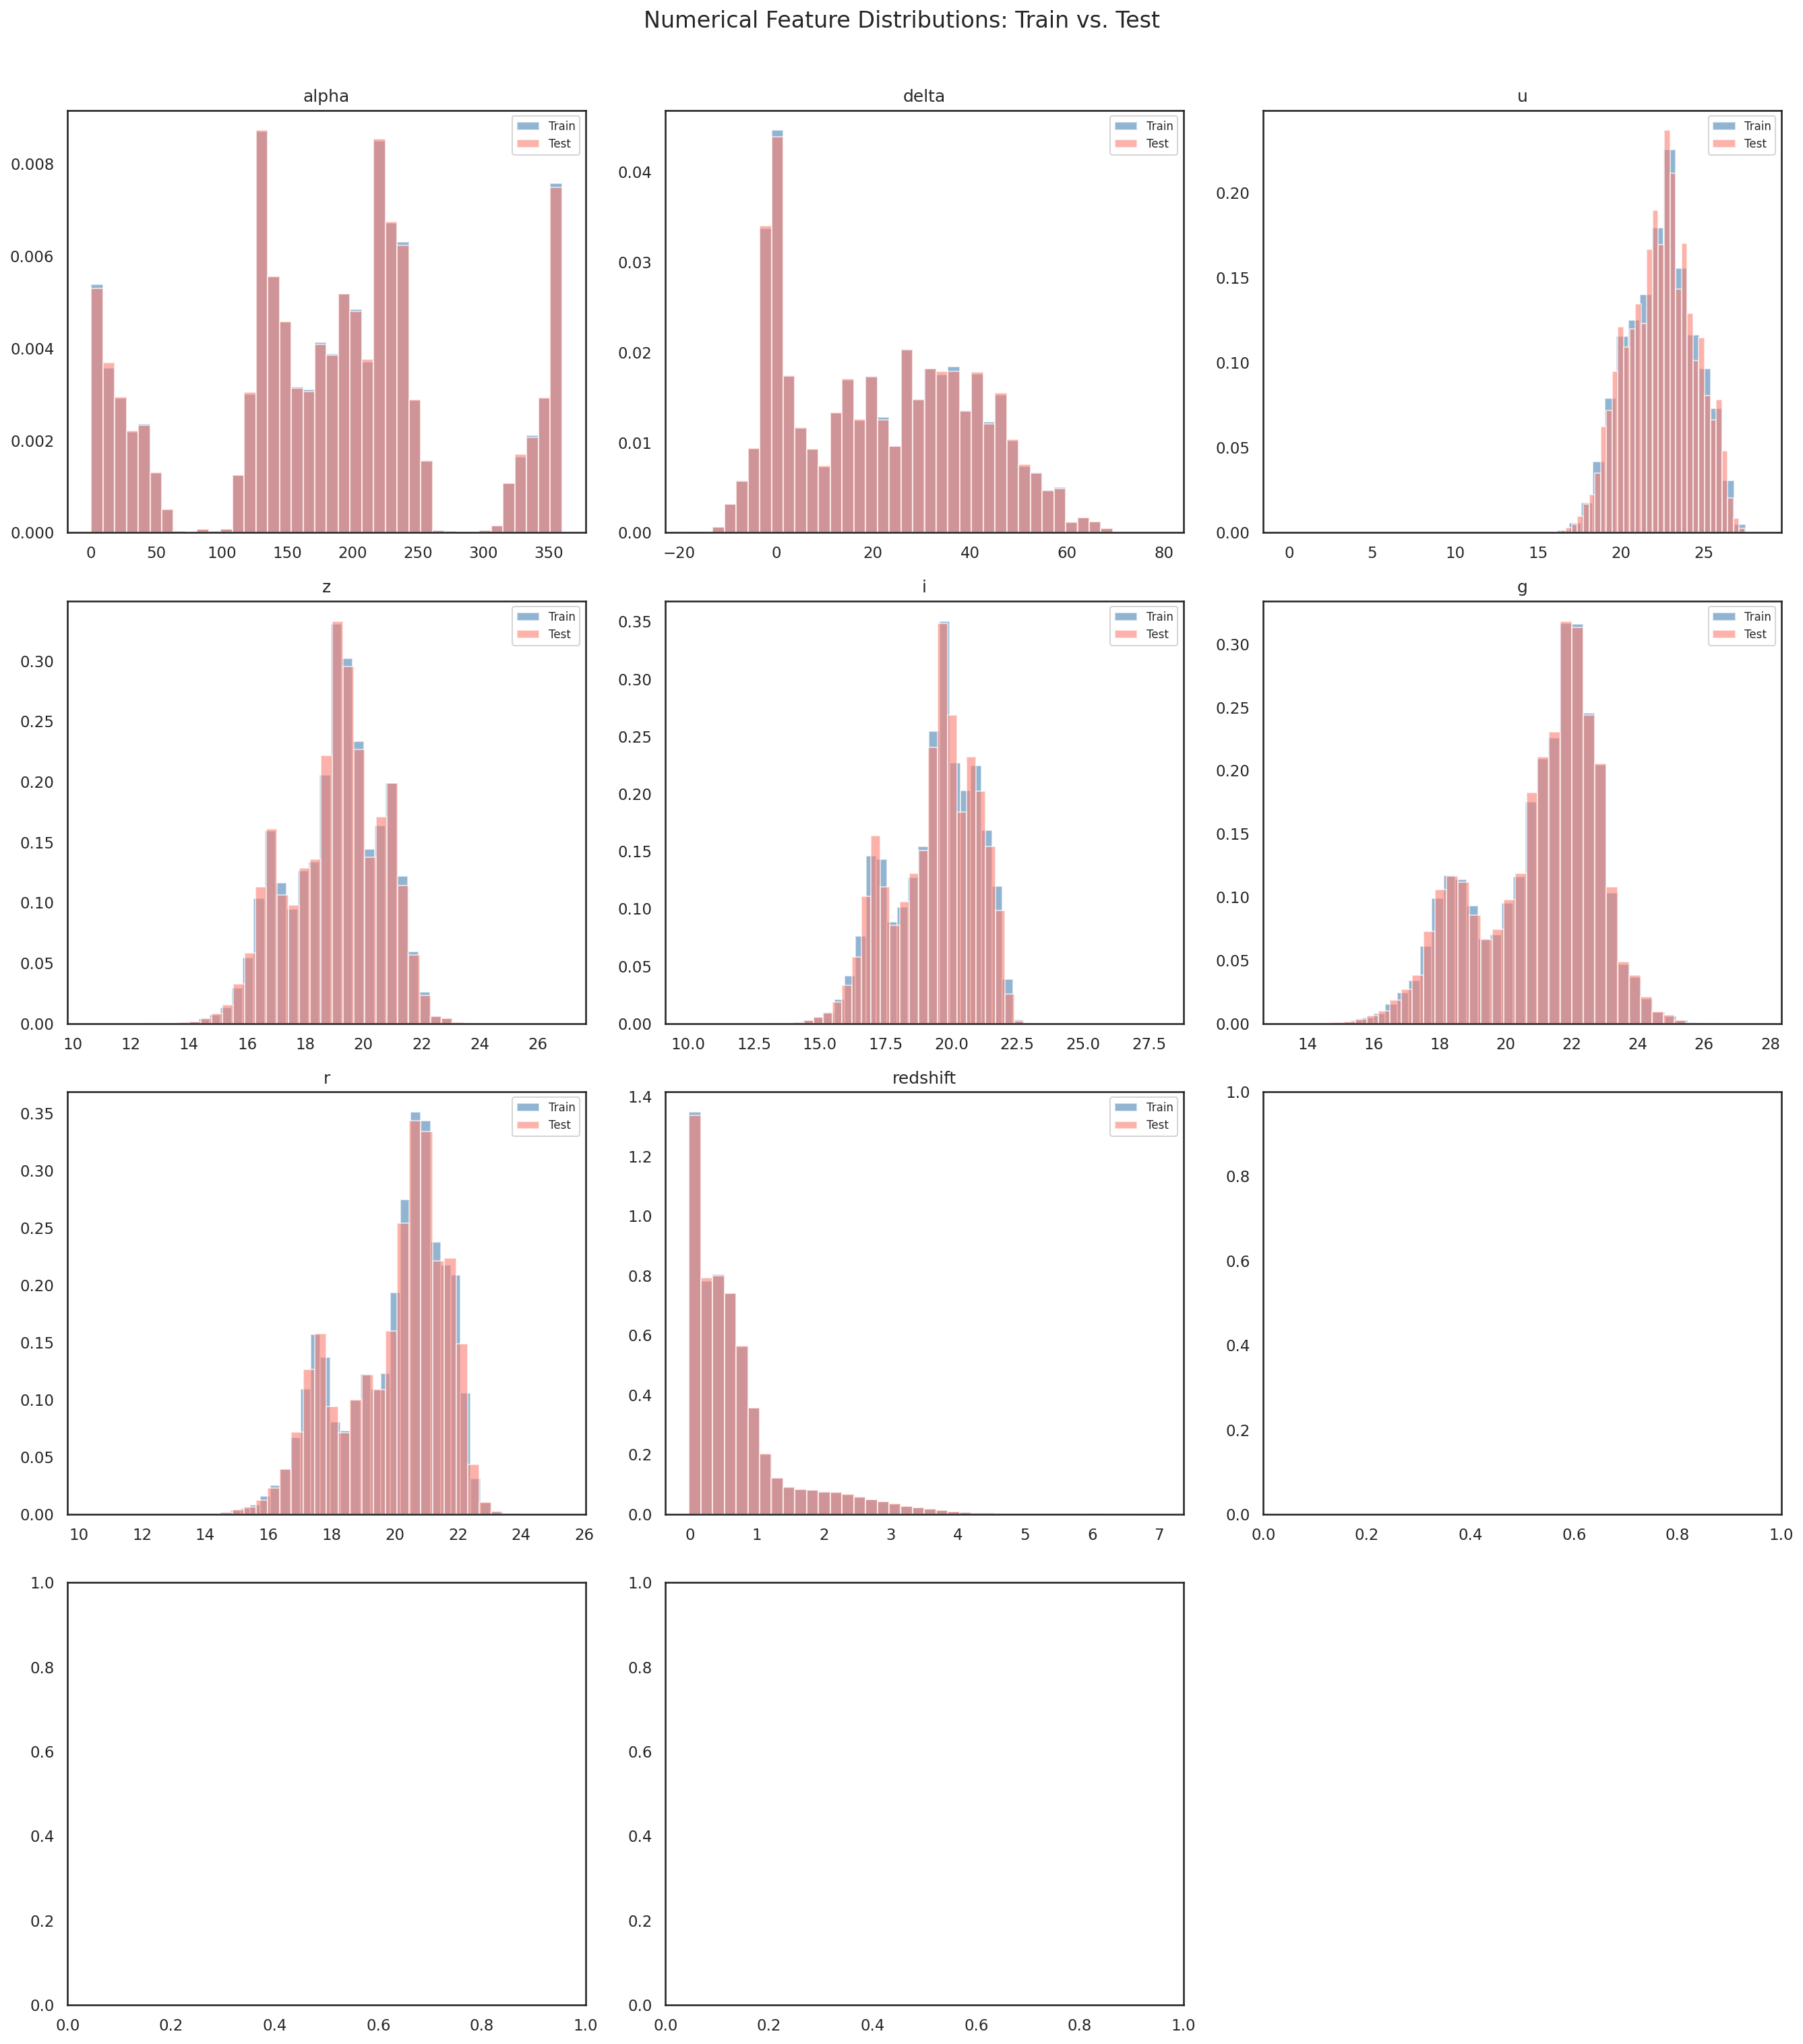

In [8]:
# Visualizing distributions of numerical features (histograms with KDE)
num_cols = ['alpha','delta','u','z','i','g','r','redshift']

fig, axes = plt.subplots(4, 3, figsize=(18, 20), dpi=150)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_train[col], bins=40, alpha=0.6, label='Train', color='steelblue', density=True)
    axes[i].hist(df_test[col],  bins=40, alpha=0.6, label='Test',  color='salmon',    density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle('Numerical Feature Distributions: Train vs. Test', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

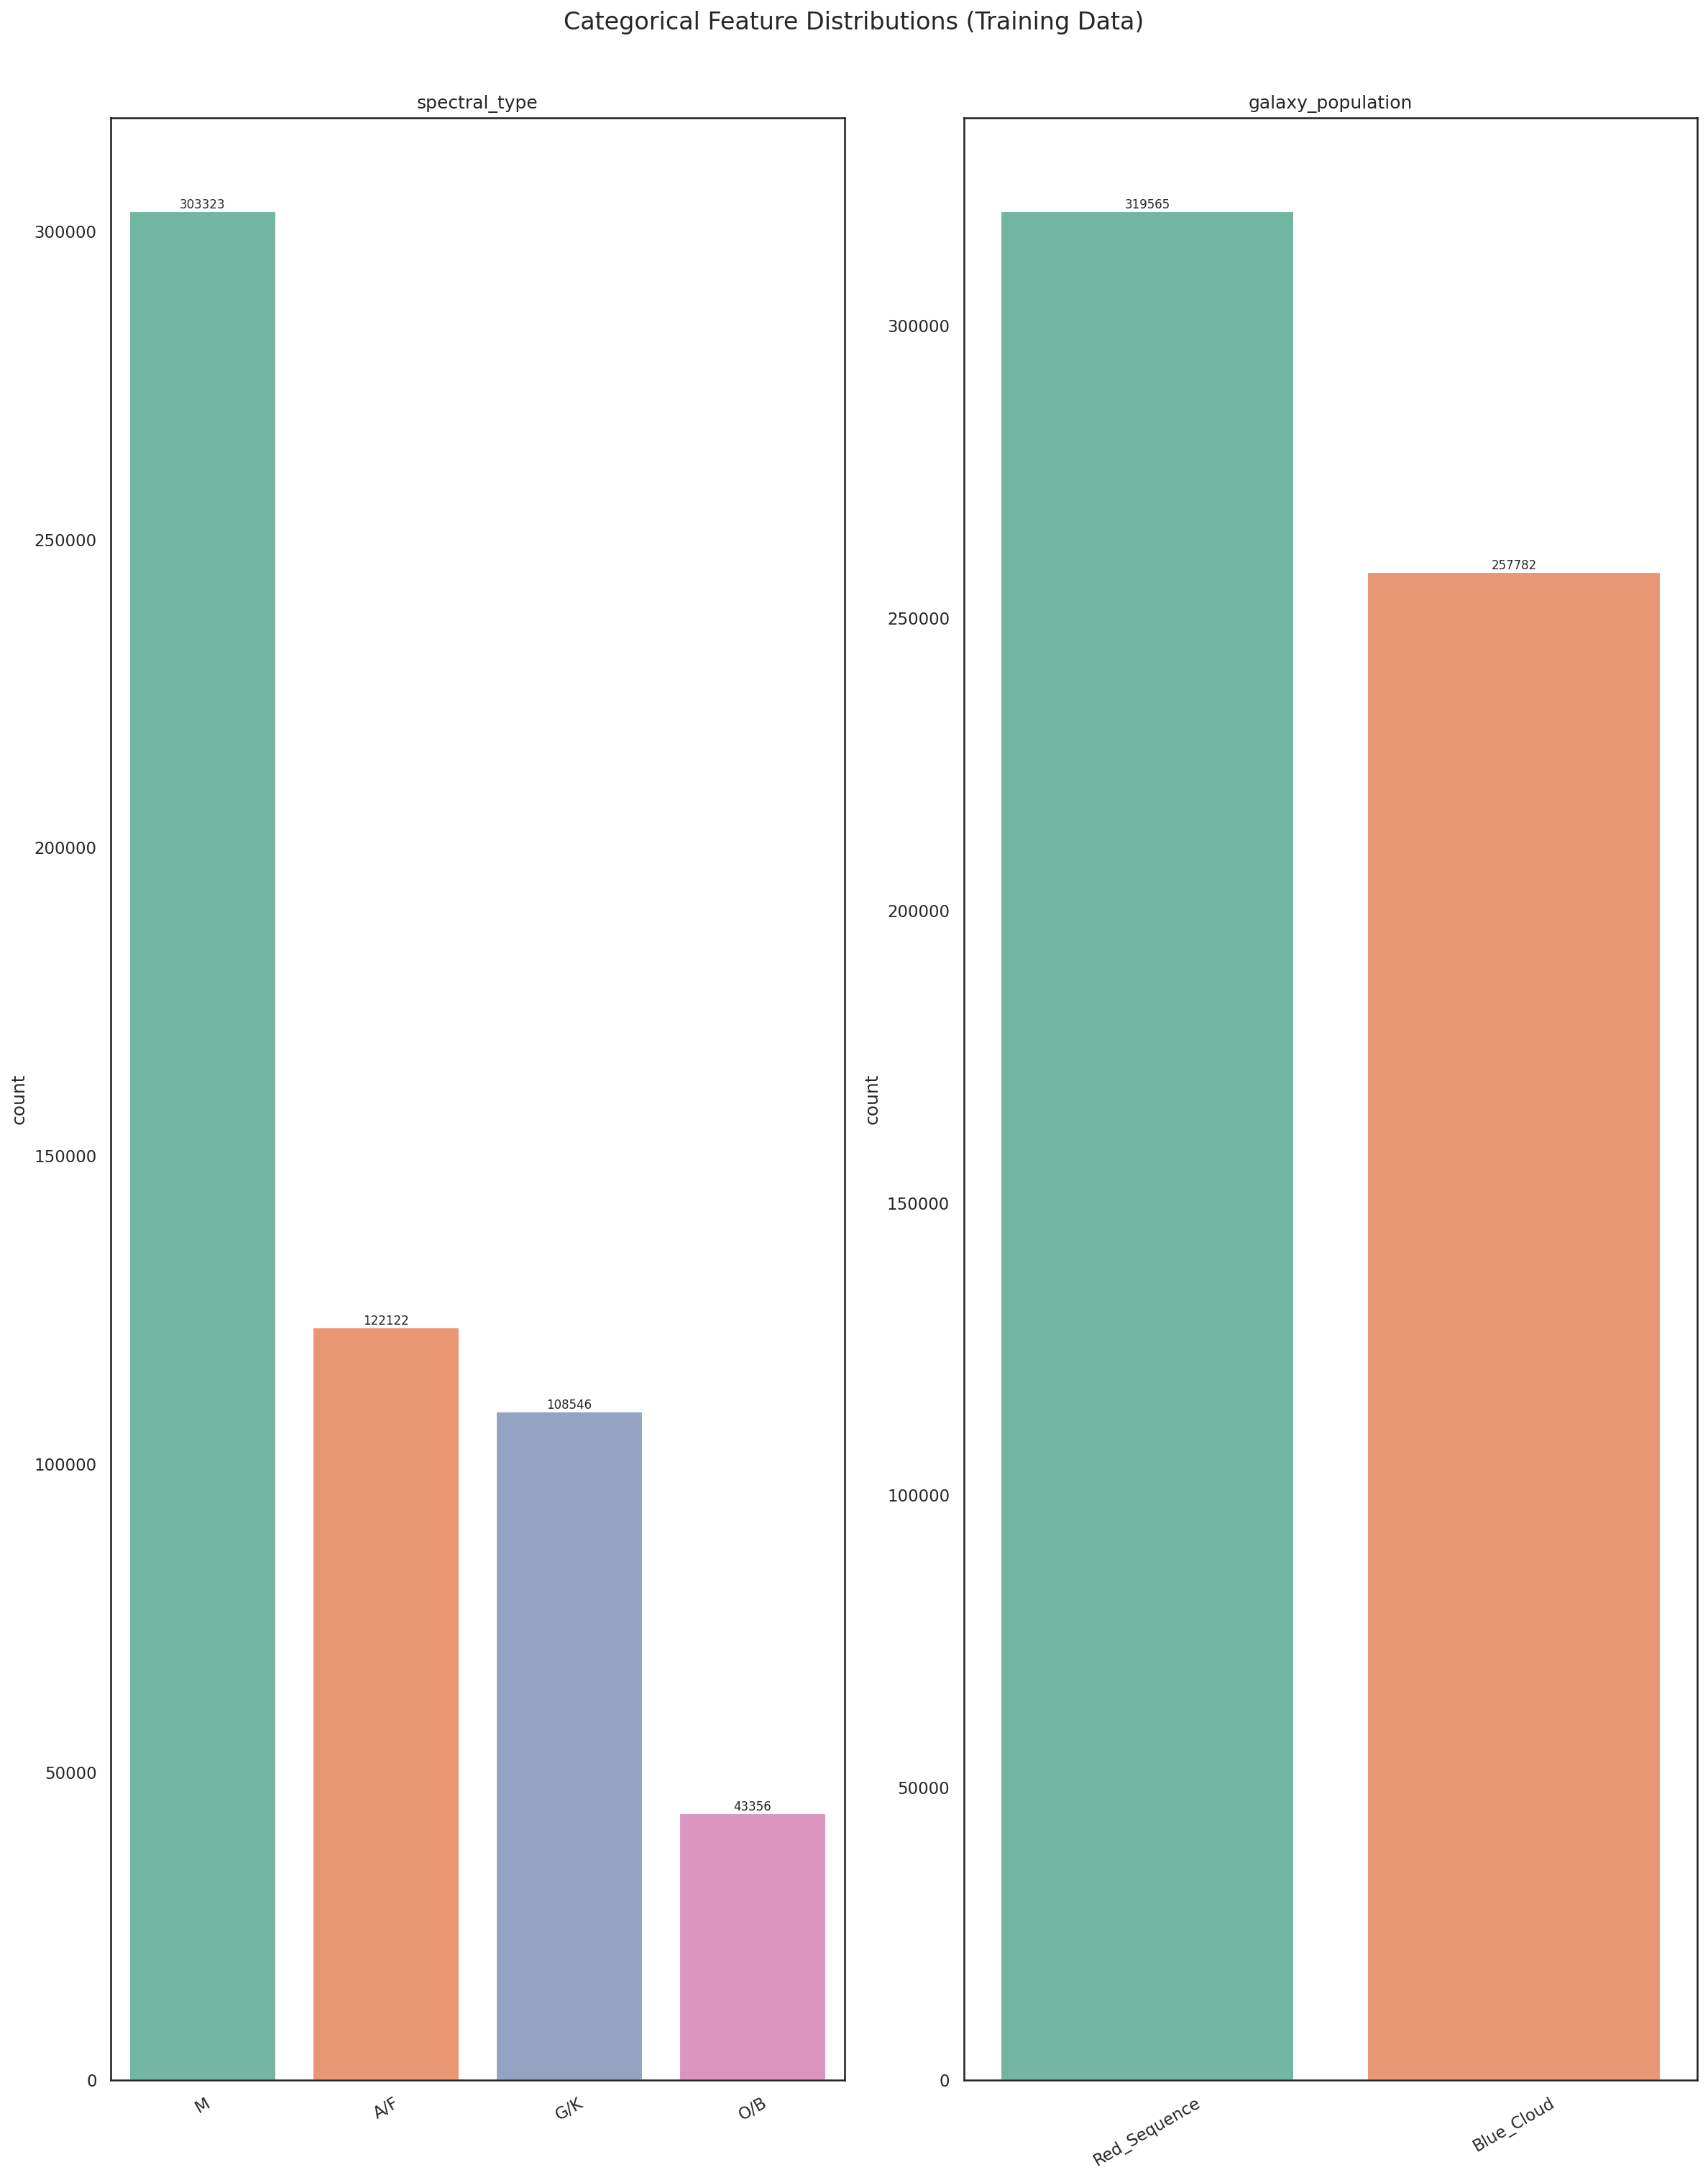

In [9]:
# Visualizing distributions of categorical features
cat_cols = ['spectral_type','galaxy_population']

fig, axes = plt.subplots(1, 2, figsize=(16, 20), dpi=150)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order_vals = df_train[col].value_counts().index
    ax = axes[i]
    sns.countplot(x=col, data=df_train, order=order_vals, ax=ax, palette='Set2')
    for label in ax.containers:
        ax.bar_label(label, fontsize=8)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Categorical Feature Distributions (Training Data)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

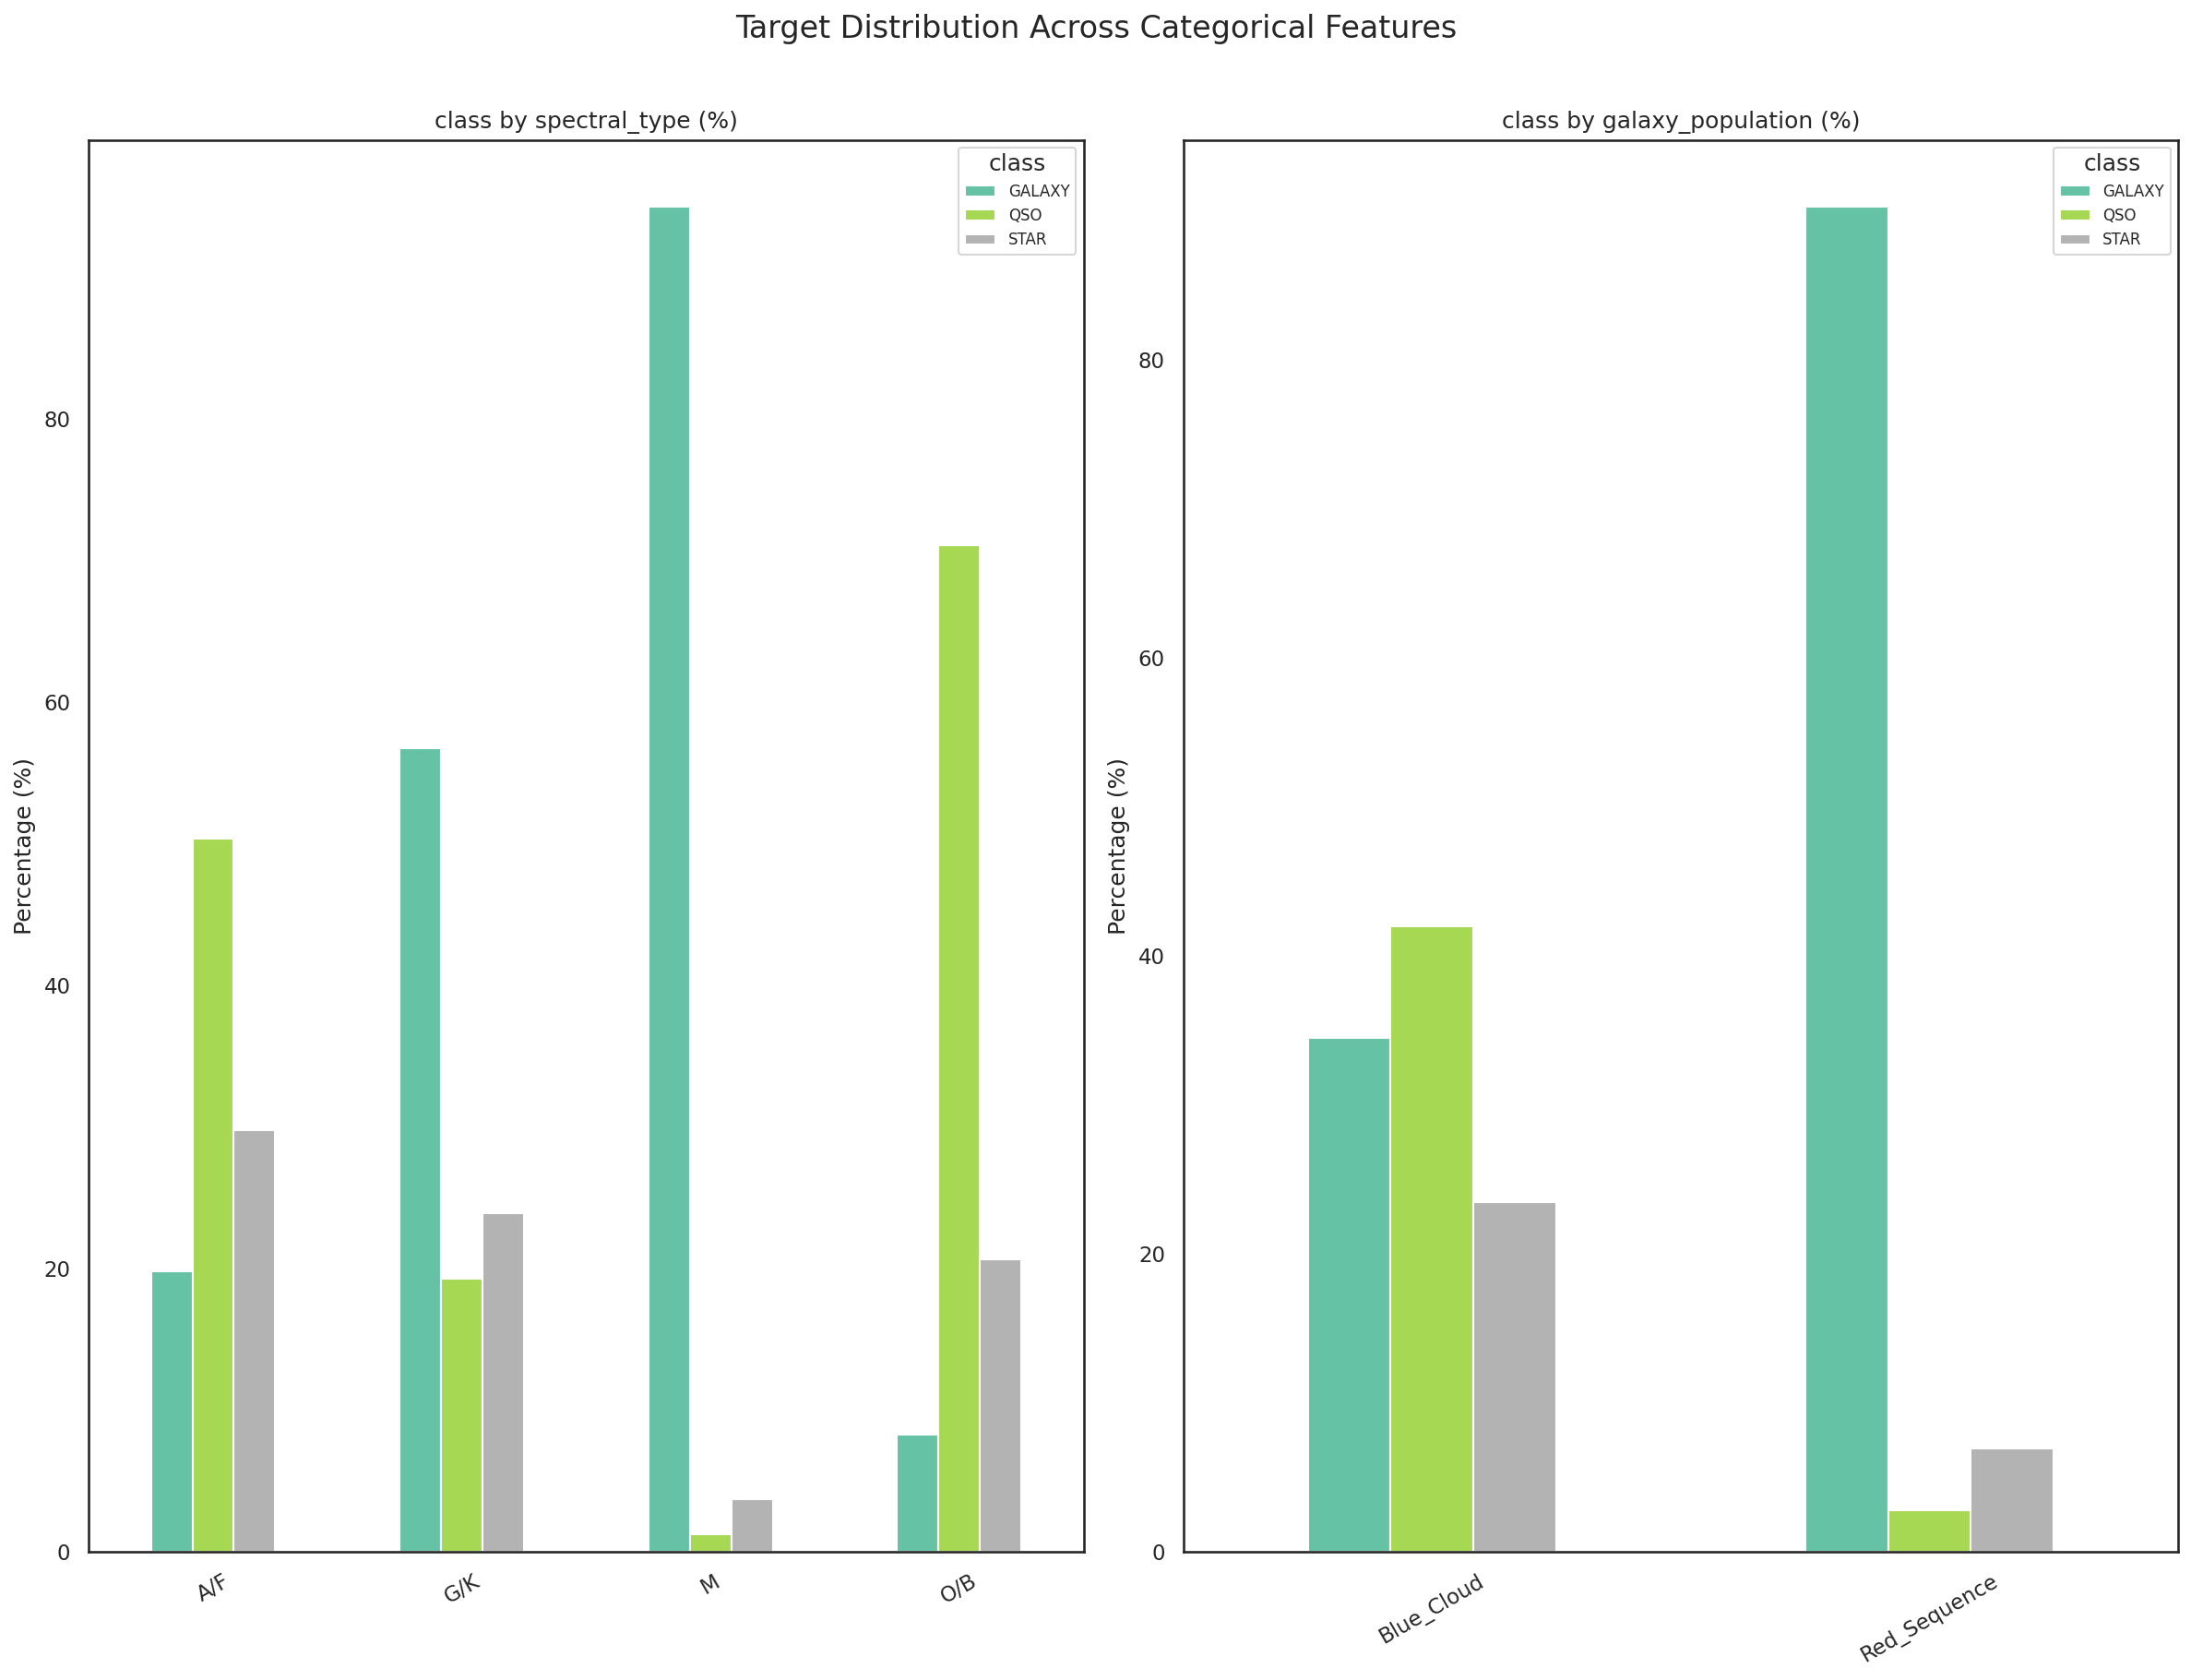

In [10]:
# Visualizing how Irrigation_Need varies across key categorical features
key_cats = ['spectral_type','galaxy_population']
fig, axes = plt.subplots(1, 2, figsize=(16, 12), dpi=150)
axes = axes.flatten()

order = ['GALAXY', 'QSO', 'STAR']
for i, col in enumerate(key_cats):
    ct = df_train.groupby(col)['class'].value_counts(normalize=True).unstack()[order] * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='white')
    axes[i].set_title(f'class by {col} (%)')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='class', loc='upper right', fontsize=8)

fig.suptitle('Target Distribution Across Categorical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

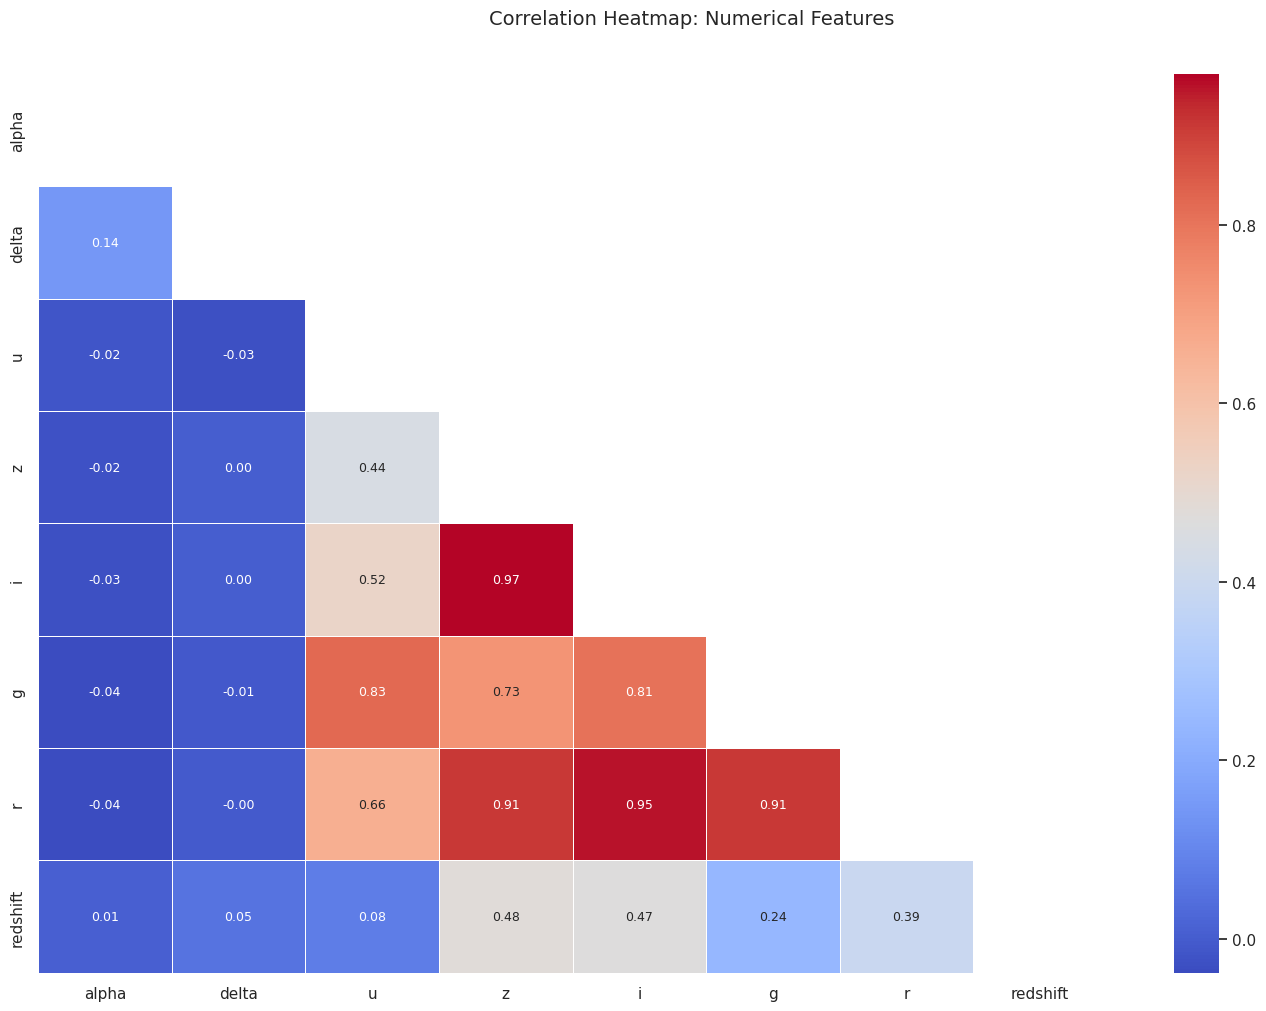

In [11]:
# Visualizing correlation heatmap (numerical features only)
plt.figure(figsize=(14, 10))
num_cols_target = ['alpha','delta','u','z','i','g','r','redshift']
corr = df_train[num_cols_target].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=np.triu(corr),
            linewidths=0.5, fmt=',.2f', annot_kws={'size': 9})
plt.suptitle('Correlation Heatmap: Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Constructing difference features between original variables effectively reduces multicollinearity, which is commonly identified from correlation heatmaps.**

# Feature Engineering(features have been adjusted according to Feature Importance Plot)

**1. Celestial Coordinate Features (from RA/Dec to Spherical Coordinates)**

alpha (Right Ascension) & delta (Declination)：
These are the "sky coordinates" of the star, similar to longitude and latitude on Earth.

sin_alpha, cos_alpha, sin_delta, cos_delta：
Directly using alpha and delta can lead to issues at the 0°/360° boundary (where 0° and 360° are the same position). Converting them to sine and cosine makes them continuous cyclic features, which tree models can handle much better.

x_sph, y_sph, z_sph：
These are the 3D Cartesian coordinates on the unit sphere. They encode the full spatial direction of the star in a way that's invariant to coordinate system rotation, which can reveal hidden patterns related to the star's location in the galaxy.


**2. Basic Color Indices**

Concept: These are differences between magnitudes in different photometric bands (u, g, r, i, z).
Purpose: A star's "color" (the difference in brightness between two wavelengths) is a fundamental indicator of its temperature, spectral type, and composition.
Why this works:
Hot stars are bluer (brighter in the u/g bands).
Cool stars are redder (brighter in the i/z bands).
The color index u-g directly measures how blue the star is, which is a strong predictor for stellar classification.

**3. Magnitude Statistics**

mag_mean: The average brightness across all bands. This is a proxy for the star's overall luminosity.

mag_range: The difference between the brightest and dimmest observed magnitudes. A large range can indicate variability or unusual spectral energy distributions.

mag_std: The standard deviation of magnitudes. Measures the "spread" of the star's brightness across the spectrum, capturing how different the star appears at different wavelengths.


**4. Redshift Transformations**

redshift:
A measure of how much the star's light has been stretched to longer wavelengths due to the expansion of the universe. It's a powerful indicator of distance and age.


log_redshift:
Compresses the range of high-redshift values, reducing the skewness of the distribution and making it easier for the model to learn patterns.


z_sq, sqrt_z, z_cu:
Polynomial and non-linear transformations. These allow the model to capture complex, non-linear relationships between redshift and the target class without having to manually define them.


**5.1 Color Index Ratios & Products**

Ratios (gr_ri, ri_iz, ug_gr):
These combine two different color indices. For example, gr_ri = (g-r) / (r-i) gives a more nuanced measure of the star's spectral energy distribution shape.

Product (gr_ri_prod):
Captures the combined effect of two features. A high value might indicate a star that is both very blue (g-r) and has a steep drop-off in red light (r-i).

**5.2 Redshift × Color Index Interactions**

 The apparent color of a star changes with redshift (due to cosmological effects). For example, a star's rest-frame ultraviolet light can be redshifted into the visible band. These features help the model account for this effect.

**5.3 Coordinate × Color Index Interactions**

Different regions of the sky have different stellar populations (e.g., the galactic plane vs. the halo). These features help the model learn location-dependent patterns.


In [12]:
# Re-loading datasets cleanly
df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
df_test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')

In [13]:
ids = df_test['id']
df_train.drop(['id'], axis=1, inplace=True)
df_test.drop(['id'], axis=1, inplace=True)
print(f'Training set shape: {df_train.shape}')
print(f'testing set shape: {df_test.shape}')

Training set shape: (577347, 11)
testing set shape: (247435, 10)


In [14]:
# Creating a function to engineer new features
def create_features(df):
    df = df.copy()
    # 1. Celestial coordinate features (RA/Dec to spherical)
    alpha = np.radians(df["alpha"])
    delta = np.radians(df["delta"])
    df["sin_alpha"]=np.sin(alpha)
    df["cos_alpha"]=np.cos(alpha)
    df["sin_delta"]=np.sin(delta)
    df["cos_delta"]=np.cos(delta)
    df["x_sph"]=df.cos_delta*df.cos_alpha
    df["y_sph"]=df.cos_delta*df.sin_alpha
    df["z_sph"]=df.sin_delta

    # 2. Basic color indices
    #Constructing difference features between original variables effectively reduces multicollinearity, 
    #which is commonly identified from correlation heatmaps.
    df["u_g"]=df.u-df.g
    df["g_r"]=df.g-df.r
    df["r_i"]=df.r-df.i
    df["i_z"]=df.i-df.z
    df["u_r"]=df.u-df.r
    df["g_i"]=df.g-df.i
    #features adjusted according to Feature Importance Plot 
    df["g_i_sq"] = df["g_i"] ** 2
    df["g_i_cu"] = df["g_i"] ** 3
    
    # Magnitude statistics
    mags=["u","g","r","i","z"]
    df["mag_mean"]=df[mags].mean(axis=1)
    df["mag_range"]=df[mags].max(axis=1)-df[mags].min(axis=1)
    df["mag_std"]=df[mags].std(axis=1)

    # 3. Redshift transformations
    z=df.redshift
    df["log_redshift"]=np.log1p(z)
    df["z_sq"]=z**2
    df["sqrt_z"]=np.sqrt(z+1e-9)
    df["z_cu"]=z**3
    #features adjusted according to Feature Importance Plot 
    df["z_g_i"] = df["log_redshift"] * df["g_i"]
    df["sqrt_z_g_i"] = df["sqrt_z"] * df["g_i"]
    df["log10_redshift"] = np.log10(z + 1e-9)  
    #df["inv_redshift"] = 1 / (z + 1e-9) 
    df["delta_redshift"] = df["delta"] * df["log_redshift"]
   
    # 4. color index ratios & products
    eps=1e-9
    df["gr_ri"]=df.g_r/(df.r_i+eps)
    df["ri_iz"]=df.r_i/(df.i_z+eps)
    df["ug_gr"]=df.u_g/(df.g_r+eps)
    df["gr_ri_prod"]=df.g_r*df.r_i

    #5.Redshift × color index interactions 
    df["z_ug"]=df.log_redshift*df.u_g
    #df["z_gr"]=df.log_redshift*df.g_r
    df["z_ri"]=df.log_redshift*df.r_i

    # Coordinate × color index interactions
    #df["x_gr"]=df.x_sph*df.g_r
    df["y_ri"]=df.y_sph*df.r_i

    # 5. Human discrete binning features 
    #df["z_bin"]=pd.qcut(df.redshift,q=4,labels=range(4)).astype(int)
    #df["gr_bin"]=pd.qcut(df.g_r,q=5,labels=range(5)).astype(int)
    df=df.drop(['u','g','r','i','z'],axis=1)
    return df

**LabelEncoder**

**We abandoned Labelencoder since in  Feature Importance Plot,category features ranked at bottom and LGB has ability to deal with category feature well**

In [15]:
cat_features = ["spectral_type", "galaxy_population"]
for col in cat_features:
    df_train[col] = df_train[col].astype("category")
    df_test[col] = df_test[col].astype("category")

le_class = LabelEncoder()
df_train['class'] = le_class.fit_transform(df_train['class'])

In [16]:
#from sklearn.preprocessing import LabelEncoder
#spectral_type
#le_target = LabelEncoder()
#df_train['spectral_type'] = le_target.fit_transform(df_train['spectral_type'])
#df_test['spectral_type'] = le_target.transform(df_test['spectral_type'])
# galaxy_population
#le_galaxy = LabelEncoder()
#df_train['galaxy_population'] = le_galaxy.fit_transform(df_train['galaxy_population'])
#df_test['galaxy_population'] = le_galaxy.transform(df_test['galaxy_population'])

# class
#le_class = LabelEncoder()
#df_train['class'] = le_class.fit_transform(df_train['class'])

In [17]:
df_train = create_features(df_train)
df_test = create_features(df_test)

print(f'After FE train shape: {df_train.shape}')
print(f'After FE test shape: {df_test.shape}')

X = df_train.drop('class', axis=1)
y = df_train['class']
X_test = df_test.copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

After FE train shape: (577347, 39)
After FE test shape: (247435, 38)
X shape: (577347, 38)
y shape: (577347,)


# feature importance

Training set shape: (461877, 38)
Validation set shape: (115470, 38)
Baseline Balanced Accuracy (Validation): 0.9626

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     75496
           1       0.95      0.97      0.96     23429
           2       0.84      0.97      0.90     16545

    accuracy                           0.96    115470
   macro avg       0.93      0.96      0.94    115470
weighted avg       0.96      0.96      0.96    115470



<Figure size 1000x800 with 0 Axes>

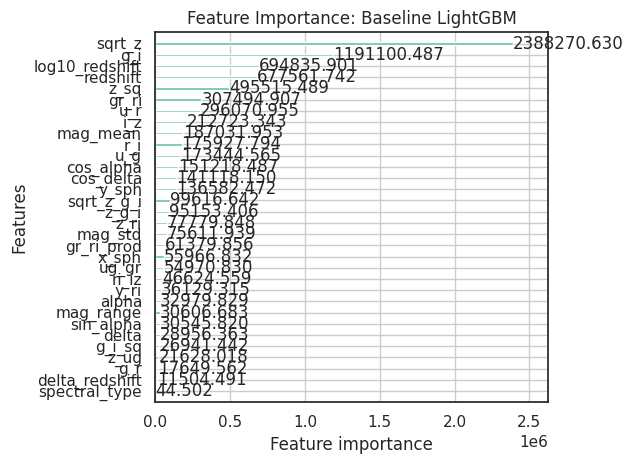

In [18]:
# 1. Split data into train and validation (for Optuna tuning)
# ==============================================
from sklearn.model_selection import train_test_split

# Stratified split to preserve class balance
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_valid.shape}")

# ==============================================
# 2. Define baseline LightGBM model
# ==============================================
import lightgbm as lgb

# Number of classes (spectral types)
n_classes = len(np.unique(y))

# Default baseline parameters
baseline_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=n_classes,
    metric='multi_logloss',
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

# Fit baseline model
baseline_model.fit(X_train, y_train)

# ==============================================
# 3. Evaluate baseline model
# ==============================================
from sklearn.metrics import balanced_accuracy_score, classification_report

y_val_pred = baseline_model.predict(X_valid)
baseline_ba = balanced_accuracy_score(y_valid, y_val_pred)

print(f"Baseline Balanced Accuracy (Validation): {baseline_ba:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, y_val_pred))

# ==============================================
# 4. Plot LightGBM feature importance
# ==============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
lgb.plot_importance(baseline_model, max_num_features=42, importance_type='gain')
plt.title('Feature Importance: Baseline LightGBM')
plt.tight_layout()
plt.show()


# Optuna

In [19]:
# Hyperparameter Tuning with Optuna for LightGBM / XGBoost / CatBoost
# ==============================================
import optuna
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

# --------------------------
# Configuration
# --------------------------
# Set to True to run Optuna search, False to skip
RUN_OPTUNA = False
# Number of trials per model (adjust based on available compute)
N_TRIALS = 50      
# Number of classes (derived from target variable)
n_classes = len(np.unique(y))


In [20]:
# 1. LightGBM Objective Function
# --------------------------
def objective_lgb(trial):
    """
    Optuna objective function for LightGBM hyperparameter tuning.
    Optimizes balanced accuracy on the validation set.
    """
    params = {
        'objective': 'multiclass',
        'num_class': n_classes,
        'metric': 'multi_logloss',
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1,
        
        # Tunable hyperparameters
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True)
    }

    # Initialize and train the model
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ],categorical_feature=cat_features
    )

    # Predict on validation set and return balanced accuracy
    y_pred = model.predict(X_valid)
    return balanced_accuracy_score(y_valid, y_pred)


In [21]:
if RUN_OPTUNA:
    print("=== Starting Optuna Hyperparameter Search ===")

    # --- LightGBM ---
    print("\n[1/3] Tuning LightGBM...")
    study_lgb = optuna.create_study(direction='maximize')
    def print_trial_callback(study, trial):
        if trial.state == optuna.trial.TrialState.COMPLETE:
            print(f"\n=== Trial {trial.number} Complete ===")
            print(f"Score: {trial.value:.6f}")
            print("Params:")
            for k, v in trial.params.items():
                print(f"  {k}: {v}")
    study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True, callbacks=[print_trial_callback])
    print(f"LightGBM - Best Balanced Accuracy: {study_lgb.best_value:.4f}")
    print(f"LightGBM - Best Parameters: {study_lgb.best_params}")

else:
    print("Skipping Optuna search. Using pre-defined default parameters.")
    # Pre-defined default parameters (can be replaced with your previous best results)
    study_lgb = type('obj', (object,), {'best_params': {
        'n_estimators': 395, 'learning_rate': 0.0876, 'num_leaves': 179,
        'max_depth': 6, 'min_child_samples': 69, 'subsample': 0.63,
        'colsample_bytree': 0.81, 'reg_alpha': 1.33, 'reg_lambda': 0.04
    }})()
# --------------------------
# LightGBM parameters
lgb_fixed = {
    'objective': 'multiclass',
    'num_class': n_classes,
    'metric': 'multi_logloss',
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}
lgb_params = {**lgb_fixed, **study_lgb.best_params}

print("\n=== Final Tuned Parameters Ready ===")

Skipping Optuna search. Using pre-defined default parameters.

=== Final Tuned Parameters Ready ===


# LGB(5-fold-cross)

In [22]:

#n_splits = 5
#skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

#oof_pred = np.zeros(len(X))       
#test_pred = np.zeros((len(X_test), 3)) 
#val_scores = []

#for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    #print(f"========== Fold {fold+1}/{n_splits} ==========")
    #X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    #y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    #model = lgb.LGBMClassifier(**lgb_params)
    #model.fit(
        #X_tr, y_tr,
        #eval_set=[(X_va, y_va)],
        #callbacks=[
            #lgb.early_stopping(stopping_rounds=50, verbose=False),
            #lgb.log_evaluation(-1)
        #],categorical_feature=cat_features
    #)

    #va_pred = model.predict(X_va)
    #oof_pred[va_idx] = va_pred
    #score = balanced_accuracy_score(y_va, va_pred)
    #val_scores.append(score)
    #print(f"Fold {fold+1} Balanced Accuracy: {score:.4f}")

    #test_pred += model.predict_proba(X_test) / n_splits

#print(f"\n===== 5-Fold CV Mean Score: {np.mean(val_scores):.4f} ± {np.std(val_scores):.4f} =====")
#print(f"Full OOF Balanced Accuracy: {balanced_accuracy_score(y, oof_pred):.4f}")

#y_test_pred = np.argmax(test_pred, axis=1)

#y_test_pred_original = le_class.inverse_transform(y_test_pred)

#submission = pd.DataFrame({
    #"id": ids,
    #"class": y_test_pred_original
#})
#submission.to_csv("submission_lgb_5fold.csv", index=False)
#print("✅")
#print(submission.head())

In [23]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

n_splits = 5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros((len(X), 3))       
test_lgb = np.zeros((len(X_test), 3)) 
val_scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)],
        categorical_feature=cat_features
    )
    
    oof_lgb[va_idx] = model.predict_proba(X_va)
    test_lgb += model.predict_proba(X_test) / n_splits
    
    va_pred = np.argmax(oof_lgb[va_idx], axis=1)
    score = balanced_accuracy_score(y_va, va_pred)
    val_scores.append(score)
    print(f"Fold {fold+1} Balanced Accuracy: {score:.4f}")

np.save("lgb_oof_probs.npy", oof_lgb)
np.save("lgb_test_probs.npy", test_lgb)
print("✅ LGB ")

oof_final_pred = np.argmax(oof_lgb, axis=1)
print(f"\nOOF Balanced Accuracy: {balanced_accuracy_score(y, oof_final_pred):.4f}")
print(f": {val_scores} | average: {np.mean(val_scores):.4f}")

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[395]	valid_0's multi_logloss: 0.103937
Fold 1 Balanced Accuracy: 0.9656
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[395]	valid_0's multi_logloss: 0.106444
Fold 2 Balanced Accuracy: 0.9653
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[395]	valid_0's multi_logloss: 0.108878
Fold 3 Balanced Accuracy: 0.9646
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[395]	valid_0's multi_logloss: 0.104895
Fold 4 Balanced Accuracy: 0.9653
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[395]	valid_0's multi_logloss: 0.106967
Fold 5 Balanced Accuracy: 0.9654
✅ LGB 

OOF Balanced Accuracy: 0.9652
: [np.float64(0.9656321734988661), np.float64(0.9652

# RealMLP

In [24]:
import math
import random
import warnings
import numpy as np, pandas as pd
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import KBinsDiscretizer, TargetEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')
print("PyTorch version:", torch.__version__)

def seed_everything(seed: int):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.10.0+cu128


In [25]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e6/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e6/test.csv")
print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (577347, 12)
Test shape : (247435, 11)


In [26]:
%%time
ID = 'id'
TARGET = 'class'
train[TARGET] = train[TARGET].map({'GALAXY': 0, 'QSO': 1, 'STAR': 2})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]
del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
color_pairs = [
    ('u', 'g'),
    ('u', 'r'),
]
important_combos = [
    ('alpha_cat_', 'delta_cat_'),
    ('u_cat_', 'z_cat_'),
]
important_combos = sorted(important_combos)
def feature_engineering(df, fit=False):
    # Arithmetic interaction
    df['_g_/_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).astype('float32')
    df['_i_/_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).astype('float32')
    for a, b in color_pairs:
        df[f"_{a}-{b}"] = (df[a] - df[b]).astype('float32')

    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype('category')

    # Categorize numericals
    for col in num_cols:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = np.floor(df[col]).factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype('category')

    # Discretize numericals
    bin_config = {'delta': [100, 500]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype('category')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category')

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, new_cat_cols, new_num_cols, combo_names = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

cat_cols = sorted(cat_cols)
X = X.reindex(sorted(X.columns), axis=1)
X_test = X_test.reindex(sorted(X_test.columns), axis=1)
print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X      init shape: (577347, 10)
X_test init shape: (247435, 10) 

init len(cat_cols): 2
init len(num_cols): 8 

len(new_cat_cols): 12
len(new_num_cols): 4 

prep len(cat_cols): 14
prep len(num_cols): 12 

X      prep shape: (577347, 26)
X_test prep shape: (247435, 26) 

CPU times: user 1.23 s, sys: 109 ms, total: 1.34 s
Wall time: 1.34 s


In [27]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
class NumericalPreprocessor(BaseEstimator, TransformerMixin):
    """
    Applies a configurable sequence of numerical transforms from CONFIG["tfms"].
    Supported: 'median_center', 'robust_scale', 'smooth_clip', 'l2_normalize'.
    'one_hot' and 'embedding' are recognised but skipped (handled by the model).
    """
    def __init__(self, tfms):
        self._tfms = [t for t in tfms
                      if t in ("median_center", "robust_scale", "smooth_clip", "l2_normalize")]

    def fit(self, X: np.ndarray, y=None):
        if "median_center" in self._tfms or "robust_scale" in self._tfms:
            self._median = np.median(X, axis=0)
            q_diff = np.quantile(X, 0.75, axis=0) - np.quantile(X, 0.25, axis=0)
            zero_idx = q_diff == 0.0
            q_diff[zero_idx] = 0.5 * (X.max(axis=0)[zero_idx] - X.min(axis=0)[zero_idx])
            self._iqr_factors = 1.0 / (q_diff + 1e-30)
            self._iqr_factors[q_diff == 0.0] = 0.0
        return self

    def transform(self, X: np.ndarray, y=None) -> np.ndarray:
        X = X.copy().astype(np.float32)
        for tfm in self._tfms:
            if tfm == "median_center":
                X -= self._median[None, :]
            elif tfm == "robust_scale":
                X *= self._iqr_factors[None, :]
            elif tfm == "smooth_clip":
                X = X / np.sqrt(1 + (X / 3) ** 2)
            elif tfm == "l2_normalize":
                norms = np.linalg.norm(X, axis=1, keepdims=True)
                X /= np.where(norms == 0, 1.0, norms)
        return X

# ── Model components ──────────────────────────────────────────────────────────
class CategoricalFeatureLayer(nn.Module):
    def __init__(self, n_ens: int, cat_dims, embed_dim: int = 8,
                 onehot_thresh: int = 8, device=None):
        super().__init__()
        self.n_ens = n_ens
        self.cat_dims = cat_dims
        self.onehot_features = []
        self.embed_layers = nn.ModuleList()
        self._embed_feature_indices = []

        for i, dim in enumerate(cat_dims):
            if dim <= onehot_thresh:
                self.onehot_features.append(i)
            else:
                emb = nn.ModuleList(
                    [nn.Embedding(dim, embed_dim) for _ in range(n_ens)]
                )
                self.embed_layers.append(emb)
                self._embed_feature_indices.append(i)

    def forward(self, x):
        # x: (batch, n_ens, n_cat)
        batch_size, n_ens, _ = x.shape
        features = []

        if self.onehot_features:
            onehot_x    = x[:, :, self.onehot_features]
            onehot_dims = [self.cat_dims[i] for i in self.onehot_features]
            total_oh    = sum(onehot_dims)
            encoded     = torch.zeros(batch_size, n_ens, total_oh, device=x.device)
            start = 0
            for idx, dim in enumerate(onehot_dims):
                pos = onehot_x[:, :, idx : idx + 1].long()
                encoded.scatter_(2, pos + start, 1.0)
                start += dim
            features.append(encoded)

        for emb_list, feat_idx in zip(self.embed_layers, self._embed_feature_indices):
            feat_embs = []
            for model_idx in range(self.n_ens):
                indices = x[:, model_idx, feat_idx : feat_idx + 1].long()
                feat_embs.append(emb_list[model_idx](indices))    # (batch, 1, embed_dim)
            feat_combined = torch.cat(feat_embs, dim=1)           # (batch, n_ens, embed_dim)
            features.append(feat_combined)

        return torch.cat(features, dim=2)


class ScalingLayer(nn.Module):
    def __init__(self, n_ens: int, n_features: int):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(n_ens, n_features))

    def forward(self, x):
        return x * self.scale[None, :, :]


class NTPLinear(nn.Module):
    def __init__(self, n_ens: int, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.randn(n_ens, in_features, out_features))
        self.bias   = nn.Parameter(torch.randn(n_ens, out_features)) if bias else None

    def forward(self, x):
        # x: (batch, n_ens, in_features)
        # Single einsum replaces transpose → matmul → transpose
        x = torch.einsum("bki,kio->bko", x, self.weight) / math.sqrt(self.in_features)
        if self.bias is not None:
            x = x + self.bias
        return x


class PBLDEmbedding(nn.Module):
    """Periodic Basis with Learned Decay embedding for numerical features."""
    def __init__(self, n_ens: int, n_features: int,
                 hidden_dim: int = 16, out_dim: int = 4, freq_scale: float = 0.1,
                 activation=nn.GELU):
        super().__init__()
        self.n_ens      = n_ens
        self.n_features = n_features
        self.out_dim    = out_dim
        self.w1 = nn.Parameter(torch.randn(n_ens, n_features, hidden_dim) * freq_scale)
        self.b1 = nn.Parameter(torch.randn(n_ens, n_features, hidden_dim))
        self.w2 = nn.Parameter(torch.randn(n_ens, n_features, hidden_dim, out_dim - 1) / math.sqrt(hidden_dim))
        self.b2 = nn.Parameter(torch.zeros(n_ens, n_features, out_dim - 1))        
        self.act = activation()
        nn.init.uniform_(self.b1, -math.pi, math.pi)

    def forward(self, x):
        # x: (batch, n_ens, n_features)
        # All operations are fully vectorised over n_features — no Python loop.

        # (batch, n_ens, n_features, 1) * (n_ens, n_features, hidden)
        # → periodic: (batch, n_ens, n_features, hidden)
        periodic = torch.cos(
            2 * math.pi * (
                x.unsqueeze(-1) * self.w1.unsqueeze(0)   # Broadcast over batch
                + self.b1.unsqueeze(0)
            )
        )

        # (batch, n_ens, n_features, hidden) @ (n_ens, n_features, hidden, out-1)
        # → transformed: (batch, n_ens, n_features, out-1)
        transformed = self.act(
            torch.einsum("bkfh,kfhd->bkfd", periodic, self.w2)
            + self.b2.unsqueeze(0)
        )

        # Concatenate raw feature (residual) with transformed output
        # x: (batch, n_ens, n_features) → unsqueeze → (batch, n_ens, n_features, 1)
        feat = torch.cat([x.unsqueeze(-1), transformed], dim=-1)
        # (batch, n_ens, n_features, out_dim) → flatten last two dims
        # → (batch, n_ens, n_features * out_dim)
        return feat.flatten(start_dim=2)

# ── Model ─────────────────────────────────────────────────────────────
class RealMLP(nn.Module):
    def __init__(self, output_dim: int, cat_dims, n_numerical: int, cfg: dict):
        super().__init__()
        n_ens      = cfg["n_ens"]
        embed_dim  = cfg["embed_dim"]
        self.n_ens = n_ens

        self.cate = CategoricalFeatureLayer(
            n_ens=n_ens, cat_dims=cat_dims, embed_dim=embed_dim,
            onehot_thresh=cfg["onehot_thresh"],
        )
        self.num_embed = PBLDEmbedding(
            n_ens=n_ens,
            n_features=n_numerical,
            hidden_dim=cfg["pbld_hidden_dim"],
            out_dim=cfg["pbld_out_dim"],
            freq_scale=cfg["pbld_freq_scale"],
            activation=cfg["pbld_activation"],
        )

        num_emb_dim = n_numerical * cfg["pbld_out_dim"]
        cat_emb_dim = sum(
            c if c <= cfg["onehot_thresh"] else embed_dim for c in cat_dims
        )
        total_dim = num_emb_dim + cat_emb_dim
        hidden_dims = cfg["hidden_dims"]

        act = cfg["activation"]

        # Build layers, tracking which NTPLinear is the "first layer"
        # so we can give it a separate lr group.
        # Each hidden position gets its own Dropout instance (shared instance
        # would only register once in nn.Sequential and break the scheduler).
        layers = []
        if cfg["add_front_scale"]:
            layers.append(ScalingLayer(n_ens=n_ens, n_features=total_dim))

        self._dropout_modules = []    # Kept for live p_drop_sched updates
        in_dim = total_dim
        for i, out_dim_h in enumerate(hidden_dims):
            linear = NTPLinear(n_ens=n_ens, in_features=in_dim, out_features=out_dim_h)
            if i == 0:
                self.first_linear = linear    # Reference for separate lr group
            drop = nn.Dropout(cfg["dropout"])
            self._dropout_modules.append(drop)
            layers += [linear, act(), drop]
            in_dim = out_dim_h

        self.hidden = nn.Sequential(*layers)
        self.output_layer = NTPLinear(n_ens=n_ens, in_features=in_dim, out_features=output_dim)

    def forward(self, x_num, x_cat):
        x_num = x_num.unsqueeze(1).expand(-1, self.n_ens, -1)
        x_cat = x_cat.unsqueeze(1).expand(-1, self.n_ens, -1)
        x_num = self.num_embed(x_num)
        x_cat = self.cate(x_cat)
        combined = torch.cat([x_num, x_cat], dim=2)
        x = self.hidden(combined)
        x = self.output_layer(x)
        return F.softmax(x, dim=2)    # (batch, n_ens, output_dim)

# ── Schedule helpers ─────────────────────────────────────────────────────────
def apply_schedule(init_value: float, progress: float, sched: str,
                   flat_ratio: float = 0.3) -> float:
    """
    Supported schedules:
      'constant'    – no decay
      'cos'         – cosine from init to 0
      'flat_cos'    – flat for flat_ratio, then cosine to 0
      'flat_anneal' – flat for flat_ratio, then linear to 0
      'sqrt_cos'    – sqrt of cosine annealing (slower decay)
      'expm4t'      – exponential decay: init * exp(-4 * progress)
    """
    if sched == "constant":
        return init_value
    elif sched == "cos":
        return init_value * (math.cos(math.pi * progress) + 1) / 2
    elif sched == "flat_cos":
        if progress < flat_ratio:
            return init_value
        t = (progress - flat_ratio) / (1 - flat_ratio)
        return init_value * (math.cos(math.pi * t) + 1) / 2
    elif sched == "flat_anneal":
        if progress < flat_ratio:
            return init_value
        t = (progress - flat_ratio) / (1 - flat_ratio)
        return init_value * (1 - t)
    elif sched == "sqrt_cos":
        return init_value * math.sqrt((math.cos(math.pi * progress) + 1) / 2)
    elif sched == "expm4t":
        return init_value * math.exp(-4 * progress)
    else:
        raise ValueError(f"Unknown schedule: '{sched}'")

# ── Per-parameter-group builder ───────────────────────────────────────────────
def get_parameter_groups(model: RealMLP, p: dict):
    """
    Five groups with independent lr / wd:
      0 – ScalingLayer params  (scale.*)
      1 – PBLD / num_embed params
      2 – first hidden linear weight
      3 – all other weights
      4 – all biases (excluding those already in groups 0-2)
    Note: PBLD has its own bias params (b1, b2) which belong to group 1, not 4.
    The ordering of checks therefore is: scale → num_embed → first_w → bias → other_w.
    """
    first_linear_weight_id = id(model.first_linear.weight)

    scale_p, pbld_p, first_w_p, other_w_p, bias_p = [], [], [], [], []
    for name, param in model.named_parameters():
        if "num_embed" in name:
            # All PBLD params (weights and biases) get their own lr group
            pbld_p.append(param)
        elif "scale" in name:
            scale_p.append(param)
        elif id(param) == first_linear_weight_id:
            first_w_p.append(param)
        elif "bias" in name:
            bias_p.append(param)
        else:
            other_w_p.append(param)

    LR = p["lr"]
    WD = p["weight_decay"]
    return [
        {"params": scale_p,   "lr": LR * p["lr_scale_mult"],         "weight_decay":  WD * p["wd_scale_mult"],         "group": "scale"},
        {"params": pbld_p,    "lr": LR * p["pbld_lr_factor"],        "weight_decay":  WD,                              "group": "pbld"},
        {"params": first_w_p, "lr": LR * p["first_layer_lr_factor"], "weight_decay":  WD * p["first_layer_wd_factor"], "group": "first_w"},
        {"params": other_w_p, "lr": LR,                              "weight_decay":  WD,                              "group": "other_w"},
        {"params": bias_p,    "lr": LR * p["lr_bias_mult"],          "weight_decay":  WD * p["wd_bias_mult"],          "group": "bias"},
    ]

# ── Multiclass label-smoothed cross-entropy with optional class weights ───────
def smooth_ce_loss(
    y_true: torch.Tensor,
    y_pred: torch.Tensor,
    ls: float = 0.0,
    class_weights: torch.Tensor = None,
) -> torch.Tensor:
    """
    y_true        : (N,)    long
    y_pred        : (N, C)  probabilities
    class_weights : (C,)    per-class weight tensor (optional)
    """
    n_classes = y_pred.size(1)
    y_smooth  = torch.full_like(y_pred, ls / n_classes)
    y_smooth.scatter_(1, y_true.unsqueeze(1), 1.0 - ls + ls / n_classes)
    per_sample_loss = -(y_smooth * torch.log(y_pred.clamp(1e-15, 1))).sum(dim=1)
    if class_weights is not None:
        sample_weights = class_weights[y_true]
        return (per_sample_loss * sample_weights).sum() / sample_weights.sum()
    return per_sample_loss.mean()

# ── Sklearn-compatible wrapper ────────────────────────────────────────────────
class RealMLP_TD_Classifier(BaseEstimator):
    """
    Sklearn-compatible wrapper around RealMLP, matching the interface of
    pytabkit's RealMLP_TD_Classifier:
    model = RealMLP_TD_Classifier(**CONFIG)
    model.fit(X_train, y_train, X_val, y_val, cat_col_names=CATS)
    proba = model.predict_proba(X_test)
    """
    def __init__(self, **kwargs):
        # Accept any subset of CONFIG keys; fall back to CONFIG defaults
        self.params = {**CONFIG, **kwargs}

    def fit(self, X_train: pd.DataFrame, y_train, X_val: pd.DataFrame, y_val,
            cat_col_names=None, ckpt_path: str = "realmlp_ckpt.pth",
            X_test: pd.DataFrame = None):
        p   = self.params
        dev = torch.device(p["device"] if torch.cuda.is_available() else "cpu")
        verbose = p["verbosity"]
        cat_col_names = cat_col_names or []
        num_col_names = [c for c in X_train.columns if c not in cat_col_names]

        # ── Split num / cat ──────────────────────────────────────────────────
        X_tr_num  = X_train[num_col_names].values.astype(np.float32)
        X_val_num = X_val[num_col_names].values.astype(np.float32)
        X_tr_cat  = X_train[cat_col_names].values.astype(np.int64)
        X_val_cat = X_val[cat_col_names].values.astype(np.int64)
        y_tr      = np.asarray(y_train)
        y_v       = np.asarray(y_val)

        # ── Numerical preprocessing ───────────────────────────────────────────
        self.preprocessor_ = NumericalPreprocessor(p["tfms"])
        self.preprocessor_.fit(X_tr_num)
        X_tr_num  = self.preprocessor_.transform(X_tr_num)
        X_val_num = self.preprocessor_.transform(X_val_num)

        # ── Categorical dims ─────────────────────────────────────────────────────────
        self.cat_col_names_ = cat_col_names
        self.num_col_names_ = num_col_names
        if cat_col_names:
            all_cat = [X_tr_cat, X_val_cat]
            if X_test is not None:
                all_cat.append(X_test[cat_col_names].values.astype(np.int64))
            cat_dims = (np.concatenate(all_cat, axis=0).max(axis=0) + 1).tolist()
        else:
            cat_dims = []
        self.cat_dims_ = cat_dims

        # Clamp indices to [0, dim-1] — -1 codes (unseen pandas categories)
        # wrap to huge ints on GPU and cause device-side assert
        if cat_dims:
            cat_max = np.array(cat_dims) - 1
            X_tr_cat  = np.clip(X_tr_cat,  0, cat_max)
            X_val_cat = np.clip(X_val_cat, 0, cat_max)

        # ── Class weights ────────────────────────────────────────────────────
        classes       = np.unique(y_tr)
        self.classes_ = classes
        weights_np    = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
        class_weights = torch.as_tensor(weights_np, dtype=torch.float32, device=dev)

        # ── Build model ──────────────────────────────────────────────────────
        n_classes    = len(classes)
        self.model_  = RealMLP(
            output_dim=n_classes,
            cat_dims=cat_dims,
            n_numerical=X_tr_num.shape[1],
            cfg=p,
        ).to(dev)

        param_groups = get_parameter_groups(self.model_, p)
        # Store the base lr on each group so the scheduler can scale from it
        for g in param_groups:
            g["lr_base"] = g["lr"]
        optimizer = torch.optim.AdamW(
            param_groups,
            betas=(p["mom"], p["sq_mom"]),
        )

        # ── To tensors ───────────────────────────────────────────────────────
        Xtn = torch.as_tensor(X_tr_num,  dtype=torch.float32, device=dev)
        Xtc = torch.as_tensor(X_tr_cat,  dtype=torch.long,    device=dev)
        ytt = torch.as_tensor(y_tr,      dtype=torch.long,    device=dev)
        Xvn = torch.as_tensor(X_val_num, dtype=torch.float32, device=dev)
        Xvc = torch.as_tensor(X_val_cat, dtype=torch.long,    device=dev)

        n_ens       = p["n_ens"]
        train_bs    = p["train_bs"]
        eval_bs     = p["eval_bs"]
        epochs      = p["epochs"]
        lr_sched    = p["lr_sched"]
        flat_ratio  = p["flat_ratio"]
        total_steps = epochs * len(y_tr)
        train_order = np.arange(len(y_tr))

        best_score      = -np.inf
        best_epoch      = 0
        best_val_probs  = None
        self.ckpt_path_ = ckpt_path

        # ── Epoch loop ───────────────────────────────────────────────────────
        for epoch in range(epochs):
            self.model_.train()
            for start in range(0, len(y_tr), train_bs):
                progress  = (epoch * len(y_tr) + start) / total_steps
                idx_batch = train_order[start : start + train_bs]

                # Update lr for each param group using its base lr
                for g in optimizer.param_groups:
                    g["lr"] = apply_schedule(g["lr_base"], progress, lr_sched, flat_ratio)

                optimizer.zero_grad()
                y_pred = self.model_(Xtn[idx_batch], Xtc[idx_batch])    # (bs, n_ens, C)

                ls_val   = apply_schedule(p["ls_eps"],  progress, p["ls_eps_sched"],  flat_ratio)
                drop_val = apply_schedule(p["dropout"], progress, p["p_drop_sched"],  flat_ratio)
                for dm in self.model_._dropout_modules:
                    dm.p = drop_val

                loss = smooth_ce_loss(
                    ytt[idx_batch].repeat_interleave(n_ens),
                    y_pred.reshape(-1, n_classes),
                    ls=ls_val,
                    class_weights=class_weights,
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model_.parameters(), p["grad_clip"])
                optimizer.step()

            np.random.shuffle(train_order)

            # ── Validation ───────────────────────────────────────────────────
            self.model_.eval()
            with torch.no_grad():
                val_probs = np.concatenate([
                    self.model_(Xvn[s : s + eval_bs], Xvc[s : s + eval_bs])
                        .mean(dim=1).cpu().numpy()
                    for s in range(0, len(y_v), eval_bs)
                ], axis=0)

            epoch_score = balanced_accuracy_score(y_v, np.argmax(val_probs, axis=1))
            improved    = epoch_score > best_score
            if improved:
                best_score     = epoch_score
                best_epoch     = epoch + 1
                best_val_probs = val_probs.copy()
                torch.save(self.model_.state_dict(), ckpt_path)

            if verbose >= 2:
                print(
                    f"  epoch {epoch + 1}/{epochs}  "
                    f"score = {epoch_score:.5f}  "
                    f"best = {best_score:.5f}  "
                    f"ls = {ls_val:.4f}  drop = {drop_val:.4f}"
                    + (" ✓" if improved else "")
                )

            # ── Early stopping ────────────────────────────────────────────────
            if p["use_early_stopping"]:
                patience = (best_epoch * p["early_stopping_multiplicative_patience"]
                            + p["early_stopping_additive_patience"])
                if (epoch + 1) > patience:
                    if verbose >= 1:
                        print(f"  Early stopping at epoch {epoch + 1} "
                              f"(best epoch {best_epoch})")
                    break

        # ── Restore best weights ──────────────────────────────────────────────
        self.model_.load_state_dict(torch.load(ckpt_path))
        self.best_score_     = best_score
        self.best_val_probs_ = best_val_probs
        self._dev            = dev
        if verbose >= 1:
            print(f"  → best score: {best_score:.5f}  (epoch {best_epoch})")
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        eval_bs = self.params["eval_bs"]
        X_num = self.preprocessor_.transform(
            X[self.num_col_names_].values.astype(np.float32)
        )
        X_cat = X[self.cat_col_names_].values.astype(np.int64)
        # Clamp to valid embedding range — guards against -1 codes (unseen
        # categories in pandas category dtype) which wrap to large ints on GPU
        X_cat = np.clip(X_cat, 0, np.array(self.cat_dims_) - 1)
        Xn = torch.as_tensor(X_num, dtype=torch.float32, device=self._dev)
        Xc = torch.as_tensor(X_cat, dtype=torch.long,    device=self._dev)
        self.model_.eval()
        with torch.no_grad():
            return np.concatenate([
                self.model_(Xn[s : s + eval_bs], Xc[s : s + eval_bs])
                    .mean(dim=1).cpu().numpy()
                for s in range(0, len(X_num), eval_bs)
            ], axis=0)

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

In [28]:
CONFIG = {
    # --- Model architecture ---
    "n_ens":         8,                # Number of ensemble members inside one RealMLP
    "embed_dim":     8,                # Embedding dim for high-cardinality categoricals  7
    "onehot_thresh": 8,                # Categoricals with nunique <= this get one-hot encoded
    "hidden_dims":   [512, 512, 512],  # MLP hidden layer sizes
    "dropout":       0.06,             # Base dropout probability value
    "p_drop_sched":  "expm4t",         # 'expm4t' | 'flat_cos' | 'constant'
    "activation":    nn.SiLU,          # Activation class for MLP layers
    "add_front_scale": True,           # Whether to prepend a ScalingLayer before MLP layers

    # --- PBLD (periodic) embedding for numericals ---
    "pbld_hidden_dim": 20,        # plr_hidden_1 in official pytabkit's API
    "pbld_out_dim":    5,         # plr_hidden_2 + 1 (includes residual raw feature)
    "pbld_freq_scale": 5.0,       # plr_sigma: init std of frequency weights
    "pbld_activation": nn.PReLU,  # plr_act_name: activation inside PBLD
    "pbld_lr_factor":  0.093,     # plr_lr_factor: PBLD param lr = lr * pbld_lr_factor

    # --- Optimizer ---
    "lr":               0.01,       # Base learning rate (weights)
    "mom":              0.9,        # Adam beta1
    "sq_mom":           0.98,       # Adam beta2
    "lr_sched":        "flat_cos",  # 'flat_cos' | 'flat_anneal' | 'cos' | 'constant'
    "flat_ratio":       0.3,        # Flat fraction for flat_cos / flat_anneal schedules
    "first_layer_lr_factor": 1.0,   # lr multiplier for first MLP layer weights
    "first_layer_wd_factor": 0.1,   # wd multiplier for first MLP layer weights
    "lr_scale_mult":    10.0,       # Scale-layer lr = lr * lr_scale_mult
    "lr_bias_mult":     0.1,        # Bias        lr = lr * lr_bias_mult
    "weight_decay":     0.013,      # Base weight decay (weights)
    "wd_scale_mult":    0.1,        # Scale-layer wd = weight_decay * wd_scale_mult
    "wd_bias_mult":     0.5,        # Bias        wd = weight_decay * wd_bias_mult
    "grad_clip":        1.0,        # Graient clipping value

    # --- Label smoothing ---
    "ls_eps":       0.04,   # Base label smoothing epsilon
    "ls_eps_sched": "cos",  # 'cos' | 'sqrt_cos' | 'constant'

    # --- Preprocessing ---
    # Supported tfms (applied in order to numerical features):
    # 'median_center', 'robust_scale', 'smooth_clip', 'l2_normalize'
    # categorical tfms ('one_hot', 'embedding') are handled separately by the model
    "tfms": ["median_center", "robust_scale"],

    # --- Training loop ---
    "epochs":    6,
    "train_bs":  256,
    "eval_bs":   10240,
    "verbosity": 2,      # 0 = silent, 1 = fold summary only, 2 = per-epoch

    # --- Early stopping ---
    "use_early_stopping":                     False,
    "early_stopping_additive_patience":       10,     # stop if epoch > best * mult + add
    "early_stopping_multiplicative_patience": 1,

    # --- Device ---
    "device":       "cuda",
    "random_state": 42,
}

# --- Fold split ---
FOLDS = 5
SEED = 42
TE = True

In [29]:
%%time
def metric(y_true, y_pred):
    y_pred = np.argmax(y_pred, axis=1)
    return balanced_accuracy_score(y_true, y_pred)

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
oof_preds = np.zeros((len(X), y.nunique()))
test_preds = np.zeros((len(X_test), y.nunique()))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr = X.iloc[tr_idx].copy()
    X_val = X.iloc[val_idx].copy()
    X_tst = X_test.copy()

    # Target encoding
    if TE:
        te_cols = combo_names
        encoder = TargetEncoder(cv=FOLDS, smooth='auto', shuffle=True, random_state=SEED)
        tr_enc = encoder.fit_transform(X_tr[te_cols], y.iloc[tr_idx])
        val_enc = encoder.transform(X_val[te_cols])
        tst_enc = encoder.transform(X_tst[te_cols])

        te_names = [f"_{col}TE_class{cls}" for col in te_cols for cls in range(y.nunique())]
        X_tr[te_names] = tr_enc
        X_val[te_names] = val_enc
        X_tst[te_names] = tst_enc    

    if fold == 1: print("len(FEATURES):", len(X_tr.columns.tolist()), "\n")
    print("#"*16)
    print(f"### Fold {fold}/{FOLDS} ...")
    print("#"*16)    

    model = RealMLP_TD_Classifier(**CONFIG)
    model.fit(
        X_tr, y.iloc[tr_idx],
        X_val, y.iloc[val_idx],
        cat_col_names=cat_cols,
        ckpt_path=f"model_fold{fold}.pth",
    )
    oof_preds[val_idx] = model.best_val_probs_
    test_preds += model.predict_proba(X_tst) / FOLDS

    fold_score = metric(y.iloc[val_idx], oof_preds[val_idx])
    print(f"\nFold {fold} | Score: {fold_score:.5f}\n")
    torch.cuda.empty_cache()

print("="*26)
print(f"Overall OOF Score: \033[1m{metric(y, oof_preds):.5f}\033[0m")
print("="*26, "\n")

len(FEATURES): 32 

################
### Fold 1/5 ...
################
  epoch 1/6  score = 0.96400  best = 0.96400  ls = 0.0373  drop = 0.0308 ✓
  epoch 2/6  score = 0.96700  best = 0.96700  ls = 0.0300  drop = 0.0158 ✓
  epoch 3/6  score = 0.96805  best = 0.96805  ls = 0.0200  drop = 0.0081 ✓
  epoch 4/6  score = 0.96937  best = 0.96937  ls = 0.0100  drop = 0.0042 ✓
  epoch 5/6  score = 0.96944  best = 0.96944  ls = 0.0027  drop = 0.0021 ✓
  epoch 6/6  score = 0.96978  best = 0.96978  ls = 0.0000  drop = 0.0011 ✓
  → best score: 0.96978  (epoch 6)

Fold 1 | Score: 0.96978

################
### Fold 2/5 ...
################
  epoch 1/6  score = 0.96410  best = 0.96410  ls = 0.0373  drop = 0.0308 ✓
  epoch 2/6  score = 0.96560  best = 0.96560  ls = 0.0300  drop = 0.0158 ✓
  epoch 3/6  score = 0.96613  best = 0.96613  ls = 0.0200  drop = 0.0081 ✓
  epoch 4/6  score = 0.96738  best = 0.96738  ls = 0.0100  drop = 0.0042 ✓
  epoch 5/6  score = 0.96782  best = 0.96782  ls = 0.0027  drop = 0

In [30]:
#  MLP OOF
np.save("mlp_oof_probs.npy", oof_preds)
np.save("mlp_test_probs.npy", test_preds)
print("RealMLP has been saved")


RealMLP has been saved


# Stacking

In [31]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

oof_lgb = np.load("lgb_oof_probs.npy")
oof_mlp = np.load("mlp_oof_probs.npy")
test_lgb = np.load("lgb_test_probs.npy")
test_mlp = np.load("mlp_test_probs.npy")

df_train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e6/train.csv")
y = df_train["class"].map({'GALAXY':0, 'QSO':1, 'STAR':2}).values


train_meta = np.hstack([oof_lgb, oof_mlp])
test_meta = np.hstack([test_lgb, test_mlp])

print(f"stacking train shape: {train_meta.shape}")
print(f"stacking test shape: {test_meta.shape}")

# =====================  Logistic  =====================
meta_clf = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)
meta_clf.fit(train_meta, y)

# ===================== 4 validation =====================
oof_final_pred = meta_clf.predict(train_meta)
final_oof_score = balanced_accuracy_score(y, oof_final_pred)
print(f"\n【Stacking + Logit OOF 】: {final_oof_score:.5f}")

lgb_single_pred = np.argmax(oof_lgb, axis=1)
mlp_single_pred = np.argmax(oof_mlp, axis=1)
print(f"LGB  OOF: {balanced_accuracy_score(y, lgb_single_pred):.5f}")
print(f"RealMLP  OOF: {balanced_accuracy_score(y, mlp_single_pred):.5f}")

# ===================== 5 submission=====================
test_final_pred = meta_clf.predict(test_meta)

label_map = {0:"GALAXY", 1:"QSO", 2:"STAR"}
final_class = [label_map[p] for p in test_final_pred]

sub = pd.DataFrame({
    "id":ids,
    "class": final_class
})
sub.to_csv("sub_stack_lgb_mlp_logit.csv", index=False)
print("\n✅ : sub_stack_lgb_mlp_logit.csv")

stacking train shape: (577347, 6)
stacking test shape: (247435, 6)

【Stacking + Logit OOF 】: 0.96893
LGB  OOF: 0.96524
RealMLP  OOF: 0.96817

✅ : sub_stack_lgb_mlp_logit.csv
